In [4]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from datamodelling import (
                Clusteringworkflow, 
                DimensionalityReduction, 
                PCAWorkflow, 
                TSNEWorkflow, 
                UMAPWorkflow)

from utils import scaling

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.preprocessing import StandardScaler


In [5]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,distinct_stores_visited,...,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_electronics,lifetime_spend_videogames,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_hygiene,lifetime_spend_petfood,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,3,...,28.0,213.0,4553.0,256.0,323.0,177.0,552.0,384.0,38.794428,-9.215739
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,2,...,43.0,15.0,963.0,333.0,533.0,95.0,1880.0,665.0,38.751711,-9.179611
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,2,...,1265.0,273.0,0.0,101.0,101.0,118.0,507.0,222.0,38.780678,-9.160656
7,John Kelling,male,44,Unknown,0,0,0,0,2021,1,...,972.0,1083.0,1105.0,1656.0,757.0,1133.0,485.0,184.0,38.739548,-9.148679
8,Arthur Dematteo,male,57,Unknown,0,0,0,0,2021,1,...,1068.0,1015.0,10841.0,1258.0,592.0,718.0,297.0,441.0,38.733071,-9.188188


In [6]:
X = dataset.select_dtypes(include='number')

X = X.reset_index()

X.columns

Index(['customer_id', 'customer_age', 'kids_home', 'teens_home',
       'total_children', 'has_children', 'year_first_transaction',
       'distinct_stores_visited', 'number_complaints', 'typical_hour',
       'hour_sin', 'hour_cos', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'latitude', 'longitude'],
      dtype='object')

In [7]:
cols_to_drop = ['customer_id', 'year_first_transaction', 'latitude', 'longitude', 'kids_home', 'teens_home']

X.drop(cols_to_drop, axis=1, inplace=True)

X.columns

Index(['customer_age', 'total_children', 'has_children',
       'distinct_stores_visited', 'number_complaints', 'typical_hour',
       'hour_sin', 'hour_cos', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood'],
      dtype='object')

In [8]:
X_scaled = scaling(X)

X_scaled

array([[ 0.05233187,  0.03158563,  0.40736893, ..., -0.84250515,
        -0.4215123 ,  0.34356915],
       [-0.22517285, -0.56923074,  0.40736893, ..., -1.00550698,
         1.74498832,  2.06930107],
       [-0.00316907, -1.17004711, -2.4547773 , ..., -0.95978695,
        -0.49492535, -0.6513368 ],
       ...,
       [ 1.43985549,  0.03158563,  0.40736893, ..., -0.96177478,
         1.48233274, -0.43024659],
       [ 1.10684982,  0.03158563,  0.40736893, ...,  0.11960324,
        -0.65317125, -0.63291261],
       [-1.05768702, -0.56923074,  0.40736893, ..., -0.94388433,
         0.84934913, -0.54693309]], shape=(32242, 20))

In [9]:
experimental_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_workflow = Clusteringworkflow(experimental_kmeans)

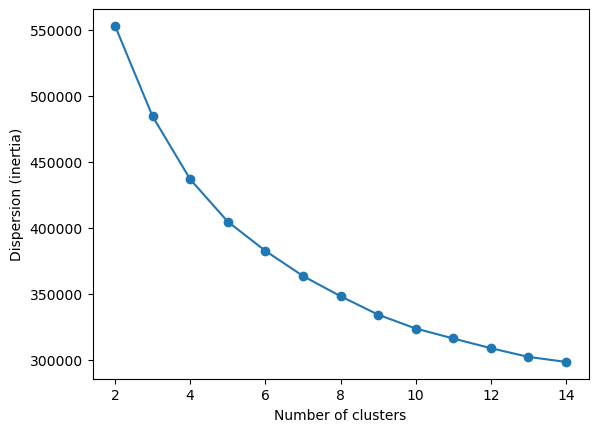

In [10]:
kmeans_workflow.find_optimal_k(X_scaled, K_range=15)

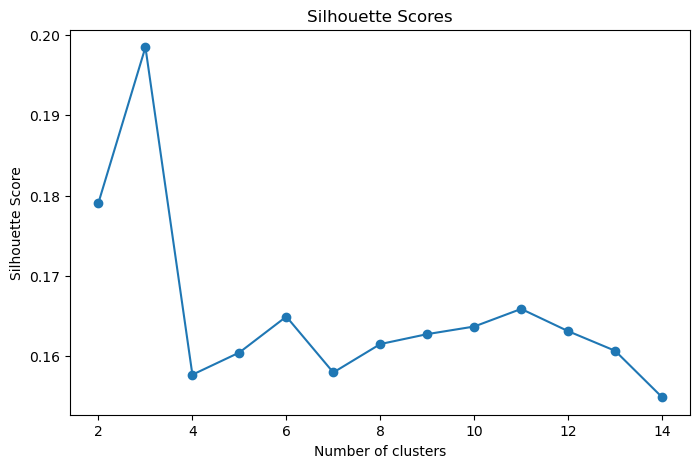

In [11]:
kmeans_workflow.silhouette(X_scaled, K_range=15)

In [ ]:
kmeans = KMeans(random_state=42, n_init=10)

kmeans_workflow = Clusteringworkflow(kmeans)
kmeans_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()


,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,...,latitude,longitude,customer_age,education_level,total_children,has_children,time_of_day,hour_sin,hour_cos,cluster_kmeans
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,1,1,1,3,11731.0,4553.0,13,373.0,...,38.794428,-9.215739,56,Bsc,2,1,Afternoon,-0.258819,-9.659258e-01,0
4,Glenda Bauman,female,1,0,0,2,13694.0,963.0,13,2012.0,...,38.751711,-9.179611,51,Bsc,1,1,Afternoon,-0.258819,-9.659258e-01,0
5,Antonio Campbell,male,0,0,1,2,12407.0,0.0,11,555.0,...,38.780678,-9.160656,55,Msc,0,0,Morning,0.258819,-9.659258e-01,0
7,John Kelling,male,0,0,2,1,7493.0,1105.0,18,84.0,...,38.739548,-9.148679,44,Unknown,0,0,Evening,-1.000000,-1.836970e-16,1
8,Arthur Dematteo,male,0,0,3,1,9187.0,10841.0,17,380.0,...,38.733071,-9.188188,57,Unknown,0,0,Afternoon,-0.965926,-2.588190e-01,1


In [ ]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
0    21168
2     7183
1     3910
Name: count, dtype: int64

In [ ]:
experimental_hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(experimental_hierarchical)

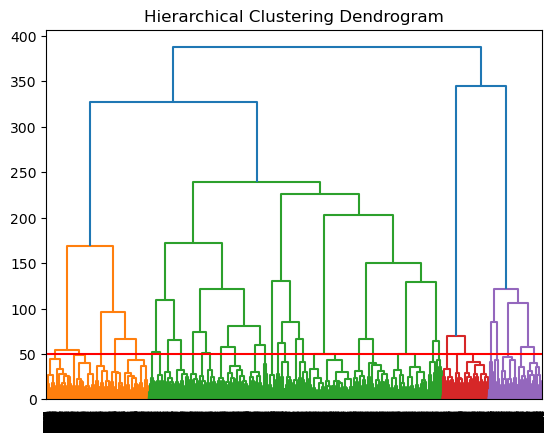

In [ ]:
hierarchical_workflow.find_optimal_k(X_scaled)

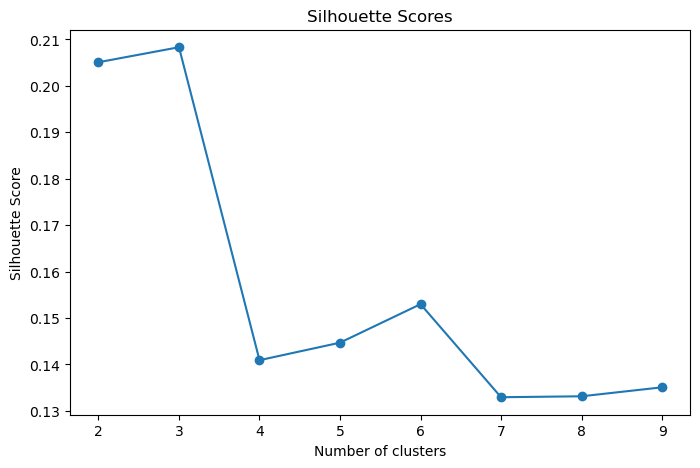

In [ ]:
hierarchical_workflow.silhouette(X_scaled, K_range=10)

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(hierarchical)

hierarchical_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()

,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,...,longitude,customer_age,education_level,total_children,has_children,time_of_day,hour_sin,hour_cos,cluster_kmeans,cluster_agglomerativeclustering
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,1,1,1,3,11731.0,4553.0,13,373.0,...,-9.215739,56,Bsc,2,1,Afternoon,-0.258819,-9.659258e-01,0,0
4,Glenda Bauman,female,1,0,0,2,13694.0,963.0,13,2012.0,...,-9.179611,51,Bsc,1,1,Afternoon,-0.258819,-9.659258e-01,0,1
5,Antonio Campbell,male,0,0,1,2,12407.0,0.0,11,555.0,...,-9.160656,55,Msc,0,0,Morning,0.258819,-9.659258e-01,0,0
7,John Kelling,male,0,0,2,1,7493.0,1105.0,18,84.0,...,-9.148679,44,Unknown,0,0,Evening,-1.000000,-1.836970e-16,1,3
8,Arthur Dematteo,male,0,0,3,1,9187.0,10841.0,17,380.0,...,-9.188188,57,Unknown,0,0,Afternoon,-0.965926,-2.588190e-01,1,3


#fazer comparação dos modelos... aquela matrix para comparar os clusters

In [ ]:
pca = PCA(n_components=2, random_state=42)

pca_workflow = PCAWorkflow(pca)
pca_workflow.fit_and_transformation(X_scaled)

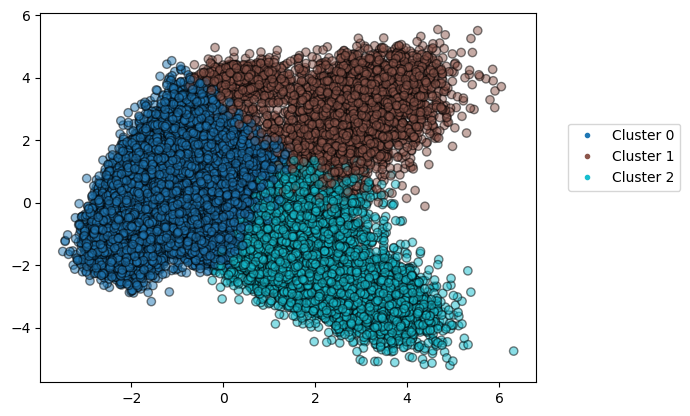

In [ ]:
pca_workflow.plot(dataset["cluster_kmeans"])

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_workflow = TSNEWorkflow(tsne)
tsne_workflow.fit_and_transformation(X_scaled)

KeyboardInterrupt: 

In [ ]:
tsne_workflow.plot(dataset["cluster_kmeans"])